In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader, random_split

In [18]:
BATCH_SIZE = 128
LEARNING_RATE = 0.001
EPOCHS = 30
NUM_CLASSES = 10

VALIDATION_SPLIT = 0.1

In [19]:
transform_train = transforms.Compose([
    
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])

transform_test = transforms.Compose([
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])

In [20]:
full_train_dataset = torchvision.datasets.CIFAR10(
    root='../data/CIFAR10',
    train=True,
    download=True,
    transform=transform_train
)

test_dataset = torchvision.datasets.CIFAR10(
    root='../data/CIFAR10',
    train=False,
    download=True,
    transform=transform_test
)

In [21]:
dataset_size = len(full_train_dataset)

val_size = int(dataset_size * VALIDATION_SPLIT)
train_size = dataset_size - val_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size]
)

In [22]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [23]:
class CNNClassifier(nn.Module):
    
    def __init__(self):
        super().__init__()
        
        self.features = nn.Sequential(
            
            nn.Conv2d(3,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            
            nn.Conv2d(32,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            
            nn.MaxPool2d(2),
            
            
            nn.Conv2d(32,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            
            nn.Conv2d(64,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            
            nn.MaxPool2d(2),
            
            
            nn.Conv2d(64,128,3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            
            nn.MaxPool2d(2)
        )
        
        self.classifier = nn.Sequential(
            
            nn.Linear(128*4*4,256),
            nn.ReLU(),
            
            nn.Dropout(0.5),
            
            nn.Linear(256,10)
        )
    
    
    def forward(self,x):
        
        x=self.features(x)
        x=torch.flatten(x,1)
        x=self.classifier(x)
        
        return x

In [24]:
model = CNNClassifier()
print(model)

CNNClassifier(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding

In [25]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=10,
    gamma=0.5
)

In [26]:
def validate_model():
    
    model.eval()
    
    total = 0
    correct = 0
    val_loss = 0
    
    
    with torch.no_grad():
        
        for images, labels in val_loader:
            
            outputs = model(images)
            
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            
            _, predicted = torch.max(outputs,1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    
    accuracy = 100 * correct / total
    
    val_loss = val_loss / len(val_loader)
    
    return val_loss, accuracy

In [27]:
def train_model():
    
    train_losses = []
    val_accuracies = []
    
    best_val_acc = 0
    
    
    for epoch in range(EPOCHS):
        
        model.train()
        
        running_loss = 0
        
        for images, labels in train_loader:
            
            optimizer.zero_grad()
            
            outputs = model(images)
            
            loss = criterion(outputs, labels)
            
            loss.backward()
            
            optimizer.step()
            
            running_loss += loss.item()
        
        
        train_loss = running_loss / len(train_loader)
        
        val_loss, val_acc = validate_model()
        
        scheduler.step()
        
        
        train_losses.append(train_loss)
        val_accuracies.append(val_acc)
        
        
        if val_acc > best_val_acc:
            
            best_val_acc = val_acc
            
            torch.save(model.state_dict(), "../checkpoints/best_model.pth")
        
        
        print(f"Epoch {epoch+1}/{EPOCHS}")
        print(f"Train Loss: {train_loss:.4f}")
        print(f"Validation Accuracy: {val_acc:.2f}%")
        print()
    
    
    return train_losses, val_accuracies

In [28]:
train_losses, val_accuracies = train_model()

Epoch 1/30
Train Loss: 1.5782
Validation Accuracy: 51.30%

Epoch 2/30
Train Loss: 1.2055
Validation Accuracy: 54.92%

Epoch 3/30
Train Loss: 1.0345
Validation Accuracy: 64.98%

Epoch 4/30
Train Loss: 0.9313
Validation Accuracy: 70.64%

Epoch 5/30
Train Loss: 0.8661
Validation Accuracy: 71.28%

Epoch 6/30
Train Loss: 0.8118
Validation Accuracy: 71.76%

Epoch 7/30
Train Loss: 0.7784
Validation Accuracy: 74.62%

Epoch 8/30
Train Loss: 0.7460
Validation Accuracy: 74.58%

Epoch 9/30
Train Loss: 0.7087
Validation Accuracy: 77.34%

Epoch 10/30
Train Loss: 0.6796
Validation Accuracy: 75.22%

Epoch 11/30
Train Loss: 0.6086
Validation Accuracy: 80.12%

Epoch 12/30
Train Loss: 0.5833
Validation Accuracy: 79.46%

Epoch 13/30
Train Loss: 0.5616
Validation Accuracy: 81.08%

Epoch 14/30
Train Loss: 0.5493
Validation Accuracy: 81.54%

Epoch 15/30
Train Loss: 0.5371
Validation Accuracy: 79.90%

Epoch 16/30
Train Loss: 0.5300
Validation Accuracy: 81.38%

Epoch 17/30
Train Loss: 0.5121
Validation Accurac

In [29]:
model.load_state_dict(torch.load("../checkpoints/best_model.pth"))

<All keys matched successfully>

In [30]:
def evaluate_model():
    
    model.eval()
    
    total = 0
    correct = 0
    
    all_preds = []
    all_labels = []
    
    
    with torch.no_grad():
        
        for images, labels in test_loader:
            
            outputs = model(images)
            
            _, predicted = torch.max(outputs,1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.numpy())
            all_labels.extend(labels.numpy())
    
    
    accuracy = 100 * correct / total
    
    print(f"\nTest Accuracy: {accuracy:.2f}%")
    
    return all_preds, all_labels

In [31]:
preds, labels = evaluate_model()


Test Accuracy: 85.92%


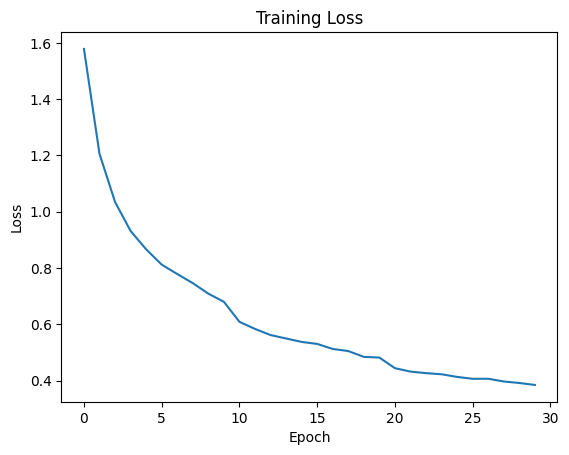

In [32]:
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

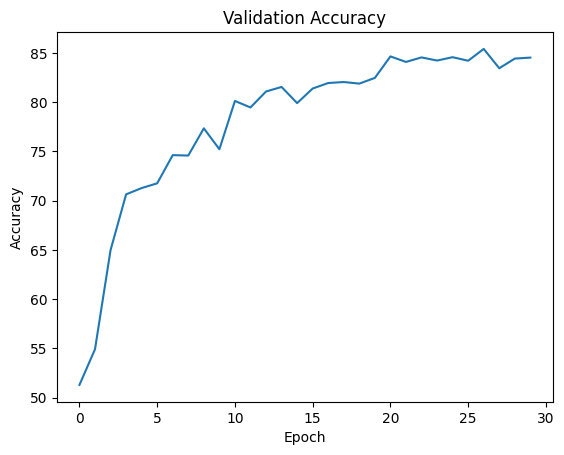

In [33]:
plt.plot(val_accuracies)
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

In [34]:
cm = confusion_matrix(labels, preds)

print(cm)

print(classification_report(labels, preds))

[[881   7  31   7   6   0   4   3  46  15]
 [  5 951   1   1   1   0   2   0  11  28]
 [ 42   0 801  29  45  24  37  14   5   3]
 [ 17   6  48 709  39 104  40  21   8   8]
 [ 10   1  34  26 867   9  21  29   3   0]
 [  7   0  37 119  32 759  10  31   3   2]
 [  5   1  34  23  14   4 912   3   3   1]
 [ 17   0  21  19  38  24   2 873   2   4]
 [ 28  10   1   7   1   0   3   3 934  13]
 [ 22  42   2   6   1   1   0   2  19 905]]
              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1000
           1       0.93      0.95      0.94      1000
           2       0.79      0.80      0.80      1000
           3       0.75      0.71      0.73      1000
           4       0.83      0.87      0.85      1000
           5       0.82      0.76      0.79      1000
           6       0.88      0.91      0.90      1000
           7       0.89      0.87      0.88      1000
           8       0.90      0.93      0.92      1000
           9       0.92     